<a href="https://colab.research.google.com/github/NDani23/CV_notebooks/blob/master/Parametric_conv&Bayesian_optimization.ipynb" 
target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fully parametric convolutional network & Bayesian optimization (Homework)

This notebook was made as a solution for a homework assignment for the "Deep learning in visual informatics" course at BME.

The objective of this notebook is to implement a modul that can build a convolutional neural network for **classification** that fits to the given parameters.

Parameters of the module:


*   nC: Number of possible classes.
*   nFeat: Number of output channels of the first layer. (Every downscaling layer after this will duple the channel size.)
*   nLevels: Number of convolutional levels.
*   layersPerLevel: Number of conv layers in one level.
*   kernelSize: Kernel size of conv layers
*   nLinType: Categorical variable for choosing the activation function.
*   bNorm: Whether to use BatchNorm or not.
*   residual: Whether to use residual linking between levels or not.



## Imports and CUDA check

In [1]:
import torch
import torch.nn as nn

!nvcc --version
haveCuda = torch.cuda.is_available()
print(haveCuda)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
True


### Module for parametric conv. layer

In [2]:
class ConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, bNorm=True, nLinType=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        #BatchNorm
        self.bn = nn.BatchNorm2d(out_channels) if bNorm else nn.Identity()

        # Choosing actiation function
        if nLinType == 0:
            self.nonLin = nn.ReLU()
        elif nLinType == 1:
            self.nonLin = nn.LeakyReLU(0.2)
        else:
            self.nonLin = nn.SiLU()

    def forward(self, x):
        return self.bn(self.nonLin(self.conv(x)))

### Module for parametric conv. level

In [4]:
class ConvLevel(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, layersPerLevel, bNorm, nLinType, residual):
        super().__init__()
        self.residual = residual

        self.in_channels_original = in_channels
        layers = []
        for _ in range(layersPerLevel):
            layers.append(ConvLayer(in_channels, out_channels, kernel_size, stride=1, bNorm=bNorm, nLinType=nLinType))
            in_channels = out_channels  # Az első réteg után a csatornák száma out_channels (csak az első szintnél van szerepe)

        self.layers = nn.Sequential(*layers)

        # Identity mapping for residual link
        self.residual_conv = nn.Conv2d(self.in_channels_original, out_channels, 1) if residual and self.in_channels_original != out_channels else nn.Identity()

    def forward(self, x):
        identity = x
        out = self.layers(x)
        if self.residual:
            identity = self.residual_conv(identity)
            out = out + identity
        return out

### Module for parametric conv. network

In [5]:
class ConvNet(nn.Module):
    def __init__(self, nC, nFeat, nLevels, layersPerLevel, kernelSize, nLinType=0, bNorm=True, residual=False):
        super().__init__()
        self.nLevels = nLevels
        current_channels = nFeat
        in_channels = 3  # RGB inputs

        levels = []
        for level in range(nLevels):
            # Creating conv. level with "layersPerLevel" number of conv. layers
            levels.append(ConvLevel(in_channels, current_channels, kernelSize, layersPerLevel, bNorm, nLinType, residual))
            # DownScale with strided convolution
            levels.append(ConvLayer(current_channels, current_channels * 2, kernelSize, stride=2, bNorm=bNorm, nLinType=nLinType))
            current_channels *= 2
            in_channels = current_channels

        self.network = nn.Sequential(*levels)

        # Adaptive pool and classifier
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Conv2d(current_channels, nC, 1)

    def forward(self, x):
        x = self.network(x)
        x = self.pool(x)
        x = self.classifier(x)
        return torch.squeeze(x)

##Training



In [6]:
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from IPython.display import HTML, display
import random
import matplotlib.pyplot as plt

### Adatbázis letöltése

In [ ]:
!wget http://deeplearning.iit.bme.hu/Public/Small.zip --no-check-certificate
!unzip -qq Small.zip
!rm Small.zip

--2025-05-10 04:52:29--  http://deeplearning.iit.bme.hu/Public/Small.zip
Resolving deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)... 152.66.243.112
Connecting to deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)|152.66.243.112|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://deeplearning.iit.bme.hu/Public/Small.zip [following]
--2025-05-10 04:52:32--  https://deeplearning.iit.bme.hu/Public/Small.zip
Connecting to deeplearning.iit.bme.hu (deeplearning.iit.bme.hu)|152.66.243.112|:443... connected.
  Issued certificate has expired.
HTTP request sent, awaiting response... 200 OK
Length: 7048374 (6.7M) [application/zip]
Saving to: ‘Small.zip’

Small.zip           100%[===================>]   6.72M  4.59MB/s    in 1.5s    

2025-05-10 04:52:34 (4.59 MB/s) - ‘Small.zip’ saved [7048374/7048374]



## Transformations for data augmentation and preparing for training

In [ ]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.25, 0.25, 0.2, 0.15),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5, 0.5, 0.5],
            [0.25, 0.25, 0.25]
        )
    ]
)

transform_val = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            [0.5, 0.5, 0.5],
            [0.25, 0.25, 0.25]
        )
    ]
)

## Creating datasets

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

trainSet = ImageFolder("Small/Classification/train/", transform)
valSet = ImageFolder("Small/Classification/val/", transform_val)

### Progress Bar

In [ ]:
from IPython.display import HTML, display

def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))

## Train function

In [ ]:
def train(epoch, net, optimizer, criterion, trainLoader, haveCuda):
    running_loss = 0
    correct = 0
    total = 0
    net.train()
    bar = display(progress(0, len(trainLoader)), display_id=True)

    for i, data in enumerate(trainLoader):
        inputs, labels = data
        if haveCuda:
            inputs, labels = inputs.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total += labels.shape[0]
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

        bar.update(progress(i+1, len(trainLoader)))

    total_loss = running_loss / len(trainLoader)
    accuracy = correct / total * 100
    print(f"Train epoch {epoch} loss: {total_loss:.3f} accuracy: {accuracy:.2f}")
    return total_loss, accuracy


## Validation function

In [ ]:
def val(epoch, net, criterion, valLoader, haveCuda):
    running_loss = 0
    correct = 0
    total = 0
    net.eval()
    bar = display(progress(0, len(valLoader)), display_id=True)

    with torch.no_grad():
        for i, data in enumerate(valLoader):
            inputs, labels = data
            if haveCuda:
                inputs, labels = inputs.cuda(), labels.cuda()

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            total += labels.shape[0]
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

            bar.update(progress(i+1, len(valLoader)))

    total_loss = running_loss / len(valLoader)
    accuracy = correct / total * 100
    print(f"Val epoch {epoch} loss: {total_loss:.3f} accuracy: {accuracy:.2f}")
    return total_loss, accuracy


## Function to visualize results

In [ ]:
#VIZUALIZÁCIÓ
def visualize(net, valLoader):
  inputs, labels = next(iter(valLoader))
  if haveCuda:
      inputs, labels = inputs.cuda(), labels.cuda()

  # forward
  outputs = net(inputs)

  _, predicted = torch.max(outputs, 1)

  mean = torch.Tensor((0.49139968, 0.48215827, 0.44653124)).unsqueeze(1).unsqueeze(1)
  std = torch.Tensor((0.24703233, 0.24348505, 0.26158768)).unsqueeze(1).unsqueeze(1)

  f, axarr = plt.subplots(2, 4,figsize=(10, 5))

  for i,(img,pred) in enumerate(zip(inputs,predicted)):
      img_rescaled = img.cpu() * std + mean
      pr = pred.cpu().item()
      name = "Field" if pr == 0 else ("Ball" if pr == 1 else ("Robot" if pr == 2 else ("Goalpost" if pr == 3 else "Line")))

      axarr[i//4,i%4].imshow(img_rescaled.permute(1,2,0))
      axarr[i//4,i%4].set_title(name)
      # Hide grid lines
      axarr[i//4,i%4].grid(False)
      # Hide axes ticks
      axarr[i//4,i%4].set_xticks([])
      axarr[i//4,i%4].set_yticks([])
      if i == 7:
          break

## Parametric training function

In [ ]:
def train_network(nC, nFeat, nLevels, layersPerLevel, kernelSize, nLinType, bNorm, residual,
                  bSize, lr, lr_ratio, numEpoch, decay):

    # Setting random seed
    torch.manual_seed(42)
    if haveCuda:
        torch.cuda.manual_seed(42)
        torch.cuda.manual_seed_all(42)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


    trainLoader = DataLoader(trainSet, bSize, shuffle = True)
    valLoader = DataLoader(valSet, bSize, shuffle = True)


    # Init network
    net = ConvNet(nC, nFeat, nLevels, layersPerLevel, kernelSize, nLinType, bNorm, residual)
    if haveCuda:
        net = net.cuda()

    # Loss & optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=decay)

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=numEpoch, eta_min=lr * lr_ratio)


    trLosses = []
    trAccs = []
    valLosses = []
    valAccs = []

    # Training cycle
    best_val_acc = 0
    for epoch in range(numEpoch):
        train_loss, train_acc = train(epoch, net, optimizer, criterion, trainLoader, haveCuda)
        val_loss, val_acc = val(epoch, net, criterion, valLoader, haveCuda)

        trLosses.append(train_loss)
        trAccs.append(train_acc)
        valLosses.append(val_loss)
        valAccs.append(val_acc)

        scheduler.step()

        # Saving best result
        if val_acc > best_val_acc:
            best_val_acc = val_acc

    plt.plot(trLosses)
    plt.plot(valLosses)
    plt.show()
    plt.plot(trAccs)
    plt.plot(valAccs)
    plt.show()

    visualize(net, valLoader)

    return best_val_acc

Train epoch 0 loss: 0.817 accuracy: 68.12


Val epoch 0 loss: 0.677 accuracy: 74.70


Train epoch 1 loss: 0.473 accuracy: 81.60


Val epoch 1 loss: 0.478 accuracy: 79.00


Train epoch 2 loss: 0.390 accuracy: 85.48


...

Val epoch 27 loss: 0.121 accuracy: 95.50


Train epoch 28 loss: 0.113 accuracy: 96.52


Val epoch 28 loss: 0.121 accuracy: 95.50


Train epoch 29 loss: 0.108 accuracy: 96.72


Val epoch 29 loss: 0.117 accuracy: 95.60


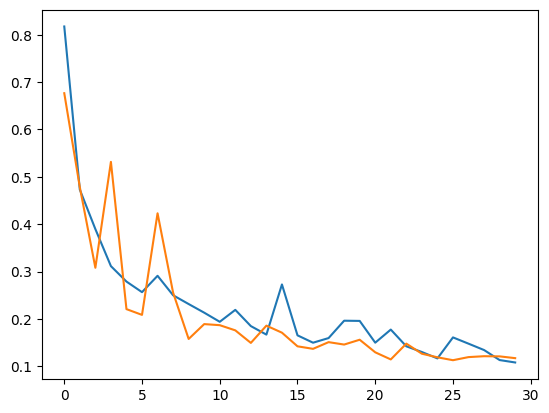

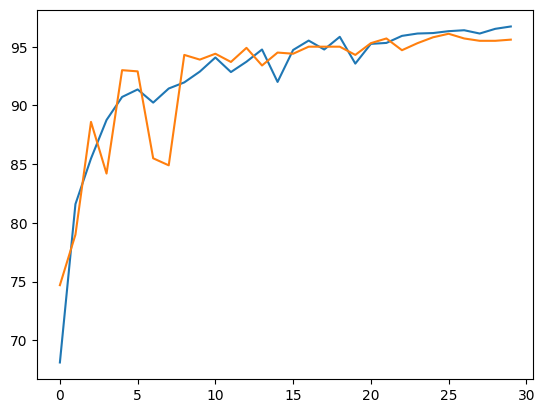

Best Acc: 96.1


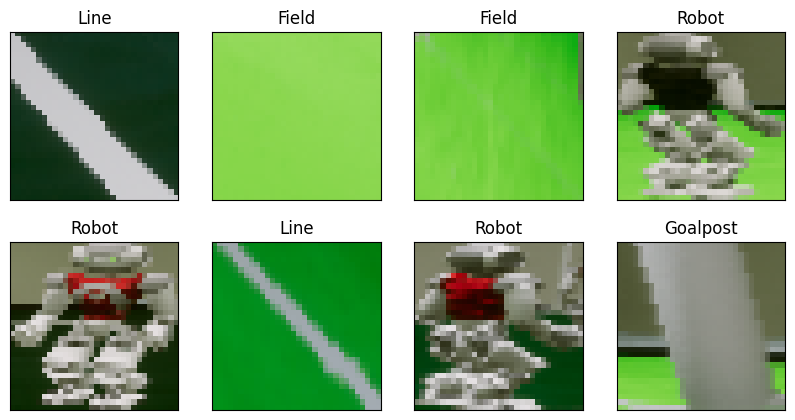

In [ ]:
#Tanítás

best_val_acc = train_network(nC=5, nFeat=21, nLevels=2, layersPerLevel=2, kernelSize=3, nLinType=0, bNorm=True, residual=True, bSize=64, lr=6e-3, lr_ratio=0.02, numEpoch=30, decay=7.8e-5)
print(f"Best Acc: {best_val_acc}")

###Using Bayesian optimization to find best hyperparameters

Link to the used implementation: https://github.com/fmfn/BayesianOptimization


In [ ]:
!pip install bayesian-optimization

In [ ]:
from bayes_opt import BayesianOptimization
import numpy as np
import math

nC = 5
nLinType = 0
bNorm = True
residual = True
numEpoch = 20

def objective(nFeat, nLevels, layersPerLevel, kernelSize, bSize, lr, lr_ratio, decay):
    nFeat = int(round(nFeat))
    nLevels = int(round(nLevels))
    layersPerLevel = int(round(layersPerLevel))
    kernelSize = 3 if kernelSize < 4 else 5
    valid_batch_sizes = [32, 64, 128, 256]
    bSize_ind = int(math.floor(bSize))
    bSize = valid_batch_sizes[bSize_ind]


    return train_network(
        nC=nC,
        nFeat=nFeat,
        nLevels=nLevels,
        layersPerLevel=layersPerLevel,
        kernelSize=kernelSize,
        nLinType=nLinType,
        bNorm=bNorm,
        residual=residual,
        bSize=bSize,
        lr=lr,
        lr_ratio=lr_ratio,
        numEpoch=numEpoch,
        decay=decay
    )

# Ranges for parameters
pbounds = {
    'nFeat': (4, 32),
    'nLevels': (1, 5),
    'layersPerLevel': (1, 3),
    'kernelSize': (2.5, 5.5),
    'bSize': (0, 4-1e-10),
    'lr': (1e-5, 1e-2),
    'lr_ratio': (0, 0.5),
    'decay': (1e-6, 1e-4)
}

# Bayesian optimization
optimizer = BayesianOptimization(
    f=objective,
    pbounds=pbounds,
    random_state=42
)

### Running the optimizer

In [ ]:
optimizer.maximize(
    init_points=8,
    n_iter=4
)

|   iter    |  target   |   bSize   |   decay   | kernel... | layers... |    lr     | lr_ratio  |   nFeat   |  nLevels  |
-------------------------------------------------------------------------------------------------------------------------
| 1         | 96.0      | 1.498     | 9.512e-05 | 4.696     | 2.197     | 0.001569  | 0.078     | 5.626     | 4.465     |
| 2         | 95.9      | 2.404     | 7.11e-05  | 2.562     | 2.94      | 0.008326  | 0.1062    | 9.091     | 1.734     |
| 3         | 96.0      | 1.217     | 5.295e-05 | 3.796     | 1.582     | 0.006122  | 0.06975   | 12.18     | 2.465     |
| 4         | 96.2      | 1.824     | 7.873e-05 | 3.099     | 2.028     | 0.005928  | 0.02323   | 21.01     | 1.682     |


KeyboardInterrupt: 

In [ ]:
print("Best parameters:", optimizer.max['params'])
print("Best validation accuracy:", optimizer.max['target'])

Best parameters: {'bSize': np.float64(1.8242799368225366), 'decay': np.float64(7.873242017790835e-05), 'kernelSize': np.float64(3.0990213464750793), 'layersPerLevel': np.float64(2.0284688768272234), 'lr': np.float64(0.0059282215429318046), 'lr_ratio': np.float64(0.023225206359998862), 'nFeat': np.float64(21.011255853240275), 'nLevels': np.float64(1.6820964947491661)}
Best validation accuracy: 96.2
